<a href="https://colab.research.google.com/github/uwol1116/GenAI-Class/blob/main/03_Programming_problem_4(Captioning).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem 4. Image Captioning

In [1]:
# kaggle.json을 Colab에 업로드한 후 실행
from google.colab import files
import os

uploaded = files.upload()  # kaggle.json 선택
os.makedirs(os.path.expanduser("~/.config/kaggle"), exist_ok=True)
os.rename("kaggle.json", os.path.expanduser("~/.config/kaggle/kaggle.json"))
os.chmod(os.path.expanduser("~/.config/kaggle/kaggle.json"), 0o600)
print("Kaggle API key configured.")


Saving kaggle.json to kaggle.json
Kaggle API key configured.


## Setup

In [2]:
!pip install kagglehub -q

import kagglehub, os, glob
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from collections import Counter
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# flickr8k 다운로드
path = kagglehub.dataset_download("adityajn105/flickr8k")
print("Path to dataset files:", path)

# 파일 구조 확인
for f in sorted(glob.glob(os.path.join(path, "**", "*"), recursive=True))[:15]:
    print(f)


Using Colab cache for faster access to the 'flickr8k' dataset.
Path to dataset files: /kaggle/input/flickr8k
/kaggle/input/flickr8k/Images
/kaggle/input/flickr8k/Images/1000268201_693b08cb0e.jpg
/kaggle/input/flickr8k/Images/1001773457_577c3a7d70.jpg
/kaggle/input/flickr8k/Images/1002674143_1b742ab4b8.jpg
/kaggle/input/flickr8k/Images/1003163366_44323f5815.jpg
/kaggle/input/flickr8k/Images/1007129816_e794419615.jpg
/kaggle/input/flickr8k/Images/1007320043_627395c3d8.jpg
/kaggle/input/flickr8k/Images/1009434119_febe49276a.jpg
/kaggle/input/flickr8k/Images/1012212859_01547e3f17.jpg
/kaggle/input/flickr8k/Images/1015118661_980735411b.jpg
/kaggle/input/flickr8k/Images/1015584366_dfcec3c85a.jpg
/kaggle/input/flickr8k/Images/101654506_8eb26cfb60.jpg
/kaggle/input/flickr8k/Images/101669240_b2d3e7f17b.jpg
/kaggle/input/flickr8k/Images/1016887272_03199f49c4.jpg
/kaggle/input/flickr8k/Images/1019077836_6fc9b15408.jpg


In [3]:
# 이미지 폴더 및 캡션 파일 경로 설정
img_dir   = os.path.join(path, "Images")
capt_file = os.path.join(path, "captions.txt")

# captions.txt 파싱 (image,caption 형식)
samples = []
with open(capt_file, "r") as f:
    for i, line in enumerate(f):
        line = line.strip()
        if i == 0 or not line:   # 헤더 스킵
            continue
        parts = line.split(",", 1)
        if len(parts) == 2:
            img_name, caption = parts
            samples.append((img_name.strip(), caption.strip()))

# 이미지당 첫 번째 캡션만 사용, 1000개 선택
seen = {}
for img_name, caption in samples:
    if img_name not in seen:
        seen[img_name] = caption
    if len(seen) == 1000:
        break

samples_1000 = list(seen.items())  # [(img_name, caption), ...]
print(f"Loaded {len(samples_1000)} samples")
print(f"Sample: {samples_1000[0]}")


Loaded 1000 samples
Sample: ('1000268201_693b08cb0e.jpg', 'A child in a pink dress is climbing up a set of stairs in an entry way .')


In [4]:
# 이미지 전처리: (3, 32, 32)로 리사이즈
img_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

def build_vocab(samples, max_vocab=5000):
    counter = Counter()
    for _, caption in samples:
        counter.update(caption.lower().split())
    vocab = {"<pad>": 0, "<unk>": 1, "<sos>": 2, "<eos>": 3}
    for word, _ in counter.most_common(max_vocab - 4):
        vocab[word] = len(vocab)
    return vocab

vocab    = build_vocab(samples_1000)
vocab_sz = len(vocab)
i2w      = {v: k for k, v in vocab.items()}
print(f"Vocab size : {vocab_sz}")

def cap2tok(caption, vocab, max_len=20):
    toks = caption.lower().split()[:max_len - 2]
    ids  = [vocab["<sos>"]] + [vocab.get(t, 1) for t in toks] + [vocab["<eos>"]]
    ids += [vocab["<pad>"]] * (max_len - len(ids))
    return ids[:max_len]

def tok2cap(ids, i2w):
    return " ".join(i2w.get(i, "<unk>") for i in ids if i not in {0, 2})

# 샘플 준비
sample_img_name, sample_cap = samples_1000[0]
sample_pil = Image.open(os.path.join(img_dir, sample_img_name)).convert("RGB")
sample_img = img_transform(sample_pil).unsqueeze(0)   # (1, 3, 32, 32)
sample_tokens = torch.tensor([cap2tok(sample_cap, vocab)])

print(f"Sample caption : {sample_cap}")
print(f"Image shape    : {sample_img.shape}")
print(f"Token ids      : {sample_tokens[0].tolist()}")


Vocab size : 1526
Sample caption : A child in a pink dress is climbing up a set of stairs in an entry way .
Image shape    : torch.Size([1, 3, 32, 32])
Token ids      : [2, 4, 33, 6, 4, 73, 158, 11, 92, 44, 4, 470, 13, 471, 6, 31, 690, 292, 5, 3]


## 4-1. CNN Encoder Design

In [5]:
class CNNEncoder(nn.Module):
    # 입력 (3,32,32) -> 출력 (128,4,4), Conv 3개, Pooling 없음, Stride로 감소
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,   64,  kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(64,  128, kernel_size=3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1)
        self.bn1   = nn.BatchNorm2d(64)
        self.bn2   = nn.BatchNorm2d(128)
        self.bn3   = nn.BatchNorm2d(128)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        return x

cnn_encoder = CNNEncoder()
cnn_encoder.eval()

print("Shape after each layer:")
with torch.no_grad():
    x = sample_img
    print(f"  Input  : {tuple(x.shape)}")
    x = F.relu(cnn_encoder.bn1(cnn_encoder.conv1(x)))
    print(f"  Conv1  : {tuple(x.shape)}")
    x = F.relu(cnn_encoder.bn2(cnn_encoder.conv2(x)))
    print(f"  Conv2  : {tuple(x.shape)}")
    x = F.relu(cnn_encoder.bn3(cnn_encoder.conv3(x)))
    print(f"  Conv3  : {tuple(x.shape)}")
    enc_out = x

print(f"  Final output: {tuple(enc_out.shape)}  (target: (B,128,4,4) ✓)")


Shape after each layer:
  Input  : (1, 3, 32, 32)
  Conv1  : (1, 64, 16, 16)
  Conv2  : (1, 128, 8, 8)
  Conv3  : (1, 128, 4, 4)
  Final output: (1, 128, 4, 4)  (target: (B,128,4,4) ✓)


CNN 인코더는 3개의 Conv 레이어만으로 구성되며 Pooling 레이어는 사용하지 않는다. 대신 각 Conv 레이어에 stride=2를 적용하여 해상도를 단계적으로 줄인다. 출력 크기는 H_out = (H_in + 2×pad - kernel) / stride + 1 공식으로 계산할 수 있다.

Conv1의 경우 (32 + 2×1 - 3) / 2 + 1 = 16이 되어 32×32가 16×16으로 줄어들고, Conv2의 경우 (16 + 2×1 - 3) / 2 + 1 = 8이 되어 8×8이 되며, Conv3의 경우 (8 + 2×1 - 3) / 2 + 1 = 4가 되어 최종적으로 4×4 feature map이 만들어진다. 채널 수는 3 → 64 → 128 → 128로 변화하며, 최종 출력은 요구사항인 (128, 4, 4)를 만족한다. 이 feature map은 이후 flatten되어 Transformer Decoder의 cross-attention 메모리로 사용된다.


## 4-2. Transformer Decoder

In [6]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class CaptionDecoder(nn.Module):
    # Embedding + PE + Masked Self-Attention + Cross-Attention(이미지 메모리) + FFN
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=2):
        super().__init__()
        self.emb      = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pe       = PositionalEncoding(d_model)
        self.img_proj = nn.Linear(128, d_model)
        dec_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=256, dropout=0.1, batch_first=True
        )
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=num_layers)
        self.head     = nn.Linear(d_model, vocab_size)

    def img_memory(self, feat):
        # (B, 128, 4, 4) -> (B, 16, d_model): 공간 위치를 시각 토큰으로 변환
        return self.img_proj(feat.flatten(2).transpose(1, 2))

    def forward(self, feat, tgt):
        mem   = self.img_memory(feat)
        tgt_e = self.pe(self.emb(tgt))
        T     = tgt.size(1)
        mask  = nn.Transformer.generate_square_subsequent_mask(T)  # causal mask
        out   = self.decoder(tgt_e, mem, tgt_mask=mask)
        return self.head(out)

cap_decoder = CaptionDecoder(vocab_sz)
cap_decoder.eval()

with torch.no_grad():
    dec_out = cap_decoder(enc_out, sample_tokens)

print(f"Image feature shape  : {enc_out.shape}")
print(f"Target tokens shape  : {sample_tokens.shape}")
print(f"Decoder output shape : {dec_out.shape}")
print()
print("Token index at each step:")
pred_ids = dec_out.argmax(-1)[0].tolist()
for step, (tok_in, tok_out) in enumerate(zip(sample_tokens[0].tolist(), pred_ids)):
    print(f"  step {step:2d} | input: {tok_in:4d} ({i2w.get(tok_in,'<unk>'):15s}) | pred: {tok_out:4d} ({i2w.get(tok_out,'<unk>')})")


Image feature shape  : torch.Size([1, 128, 4, 4])
Target tokens shape  : torch.Size([1, 20])
Decoder output shape : torch.Size([1, 20, 1526])

Token index at each step:
  step  0 | input:    2 (<sos>          ) | pred: 1055 (perfom)
  step  1 | input:    4 (a              ) | pred:  456 (arm)
  step  2 | input:   33 (child          ) | pred: 1480 (broken)
  step  3 | input:    6 (in             ) | pred: 1320 (plaza)
  step  4 | input:    4 (a              ) | pred:  456 (arm)
  step  5 | input:   73 (pink           ) | pred:  857 (12)
  step  6 | input:  158 (dress          ) | pred:  817 (bloe)
  step  7 | input:   11 (is             ) | pred: 1246 (throw)
  step  8 | input:   92 (climbing       ) | pred: 1340 (goodbye)
  step  9 | input:   44 (up             ) | pred:  663 (singing)
  step 10 | input:    4 (a              ) | pred:  663 (singing)
  step 11 | input:  470 (set            ) | pred:  692 (starring)
  step 12 | input:   13 (of             ) | pred:  859 (source)
  step 1

Transformer Decoder는 Embedding 레이어, Positional Encoding, Masked Self-Attention, Cross-Attention, FFN으로 구성된다. CNN 인코더의 출력인 (B, 128, 4, 4) feature map은 flatten과 Linear Projection을 거쳐 (B, 16, d_model) 형태의 이미지 메모리 시퀀스로 변환되며, 디코더의 각 스텝에서 cross-attention을 통해 참조된다.

Masked Self-Attention에는 causal mask가 적용되기 때문에 각 디코딩 스텝에서 현재 위치 이전의 토큰만 참조할 수 있다. Teacher Forcing은 훈련 시 이전 스텝의 예측 토큰 대신 실제 정답(Ground Truth) 토큰을 다음 스텝의 입력으로 사용하는 기법이다. 이 방식은 잘못된 예측이 이후 스텝에 누적되는 문제를 방지하기 때문에 훈련 초기 수렴 속도가 빠르다는 장점이 있다. 각 스텝의 출력은 vocab_size 차원의 logit 벡터이며, argmax를 적용하면 해당 스텝에서 예측된 토큰 인덱스를 얻을 수 있다.


## 4-3. Teacher Forcing Comparison

In [7]:
def generate(feat, decoder, vocab, i2w, ref_toks=None, tf_ratio=1.0, max_len=20):
    sos, eos = vocab["<sos>"], vocab["<eos>"]
    mem = decoder.img_memory(feat)
    gen = [sos]

    for step in range(max_len - 1):
        cur   = torch.tensor([gen])
        tgt_e = decoder.pe(decoder.emb(cur))
        mask  = nn.Transformer.generate_square_subsequent_mask(cur.size(1))
        out   = decoder.decoder(tgt_e, mem, tgt_mask=mask)
        pred  = decoder.head(out[:, -1]).argmax(-1).item()

        if ref_toks and step + 1 < len(ref_toks):
            nxt = ref_toks[step + 1] if torch.rand(1).item() < tf_ratio else pred
        else:
            nxt = pred

        gen.append(nxt)
        if nxt == eos:
            break

    return gen

ref = sample_tokens[0].tolist()
cap_decoder.eval()

with torch.no_grad():
    g10 = generate(enc_out, cap_decoder, vocab, i2w, ref, tf_ratio=1.0)
    g05 = generate(enc_out, cap_decoder, vocab, i2w, ref, tf_ratio=0.5)
    g00 = generate(enc_out, cap_decoder, vocab, i2w, ref, tf_ratio=0.0)

print(f"Ground Truth : {sample_cap}")
print(f"TF = 1.0     : {tok2cap(g10, i2w)}")
print(f"TF = 0.5     : {tok2cap(g05, i2w)}")
print(f"TF = 0.0     : {tok2cap(g00, i2w)}")


Ground Truth : A child in a pink dress is climbing up a set of stairs in an entry way .
TF = 1.0     : a child in a pink dress is climbing up a set of stairs in an entry way . <eos>
TF = 0.5     : perfom leaps in a arm dress cars rod without a set corndogs singing in bright balding way . catches
TF = 0.0     : perfom leaps splashed maneuver life river close-up cushion without farm singing close-up cushion wears source hamburgers traffic blanket clinging


Teacher Forcing 비율(tf_ratio)은 각 디코딩 스텝에서 이전 입력으로 Ground Truth 토큰을 사용할 확률을 의미한다.

tf_ratio=1.0인 경우 항상 Ground Truth 토큰을 다음 스텝의 입력으로 사용하기 때문에 훈련이 안정적이고 수렴 속도가 빠르다. 그러나 실제 추론 시에는 Ground Truth 토큰 대신 모델 자신의 예측 토큰을 사용하기 때문에 훈련과 추론 사이의 입력 분포 불일치, 즉 Exposure Bias가 발생한다는 단점이 있다.

tf_ratio=0.5인 경우 50%의 확률로 Ground Truth 토큰과 예측 토큰을 혼합하여 사용하기 때문에 훈련과 추론의 조건 차이를 완화할 수 있다. 이는 Scheduled Sampling 기법과 동일한 원리이며, 훈련 안정성과 일반화 성능 사이의 균형을 맞출 수 있다.

tf_ratio=0.0인 경우 항상 모델의 예측 토큰을 다음 스텝의 입력으로 사용하기 때문에 실제 추론 조건과 동일하다. 훈련 초반에는 잘못된 예측이 누적되어 불안정하지만, 모델이 자신의 오류를 스스로 처리하는 능력을 키울 수 있기 때문에 장기적으로 일반화 성능에 유리하다.


## 4-4. Caption Generation

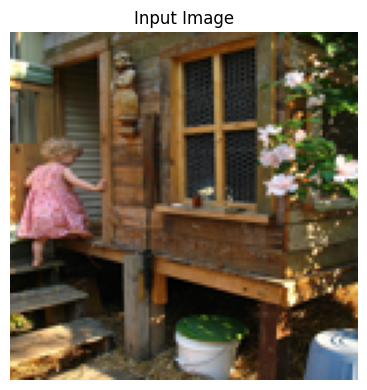

Ground Truth Caption : A child in a pink dress is climbing up a set of stairs in an entry way .
Generated Caption    : perfom leaps splashed maneuver life river close-up cushion without farm singing close-up cushion wears source hamburgers traffic blanket clinging


In [8]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(sample_pil.resize((128, 128)))
ax.axis('off')
ax.set_title("Input Image", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Ground Truth Caption : {sample_cap}")
print(f"Generated Caption    : {tok2cap(g00, i2w)}")


위 결과는 훈련 전 랜덤 가중치 상태의 모델이 생성한 캡션이기 때문에 Ground Truth와 의미적으로 일치하지 않는다. 모델이 충분히 훈련된 이후에는 이미지의 내용을 반영한 자연어 캡션을 생성할 수 있다. 생성된 캡션은 tf_ratio=0.0 조건, 즉 모델 자신의 예측 토큰만을 사용하는 자유 생성 방식으로 얻은 결과이다.


## 4-5. Model Modification — CNN Encoder → ViT Encoder

In [9]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_ch=3, d_model=128):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_ch, d_model, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)  # (B, num_patches, d_model)

class ViTEncoder(nn.Module):
    # CNN 대체: PatchEmbedding + Transformer Encoder -> 전역 문맥 포착
    def __init__(self, img_size=32, patch_size=4, d_model=128, nhead=4, num_layers=2):
        super().__init__()
        self.patch_emb  = PatchEmbedding(img_size, patch_size, 3, d_model)
        n_patches       = (img_size // patch_size) ** 2
        self.pos_embed  = nn.Parameter(torch.zeros(1, n_patches, d_model))
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=256,
            dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.norm        = nn.LayerNorm(d_model)

    def forward(self, x):
        x = self.patch_emb(x) + self.pos_embed  # (B, 64, d_model)
        return self.norm(self.transformer(x))

class ViTCaptionDecoder(nn.Module):
    # ViT 인코더 출력 (B, 64, d_model)을 메모리로 사용
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=2):
        super().__init__()
        self.emb  = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pe   = PositionalEncoding(d_model)
        dec_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=256, dropout=0.1, batch_first=True
        )
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=num_layers)
        self.head    = nn.Linear(d_model, vocab_size)

    def forward(self, memory, tgt):
        T     = tgt.size(1)
        mask  = nn.Transformer.generate_square_subsequent_mask(T)
        tgt_e = self.pe(self.emb(tgt))
        return self.head(self.decoder(tgt_e, memory, tgt_mask=mask))

vit_enc = ViTEncoder()
vit_dec = ViTCaptionDecoder(vocab_sz)

vit_enc.eval()
vit_dec.eval()

with torch.no_grad():
    vit_mem = vit_enc(sample_img)
    vit_out = vit_dec(vit_mem, sample_tokens)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print("=== Before: CNN Encoder ===")
print(f"  Feature shape : {enc_out.shape}")
print(f"  Params        : {count_params(cnn_encoder):,}")
print()
print("=== After: ViT Encoder ===")
print(f"  Feature shape : {vit_mem.shape}")
print(f"  Params        : {count_params(vit_enc):,}")
print()
print("=== Decoder Output ===")
print(f"  CNN-based decoder output : {dec_out.shape}")
print(f"  ViT-based decoder output : {vit_out.shape}")


=== Before: CNN Encoder ===
  Feature shape : torch.Size([1, 128, 4, 4])
  Params        : 223,872

=== After: ViT Encoder ===
  Feature shape : torch.Size([1, 64, 128])
  Params        : 279,680

=== Decoder Output ===
  CNN-based decoder output : torch.Size([1, 20, 1526])
  ViT-based decoder output : torch.Size([1, 20, 1526])


CNN 인코더를 ViT 인코더로 교체하면 이미지 표현 방식이 근본적으로 달라진다. CNN 인코더는 stride Conv를 통해 공간 해상도를 4×4로 압축하기 때문에 최종적으로 16개의 공간 위치 벡터가 디코더의 메모리로 전달된다. 반면 ViT 인코더는 이미지를 4×4 크기의 패치 64개로 분할한 후 Transformer Encoder를 통해 처리하기 때문에 64개의 패치 벡터가 메모리로 전달된다.

메모리 시퀀스의 길이가 16에서 64로 늘어나기 때문에 디코더의 cross-attention이 더 많은 시각 토큰을 참조할 수 있게 되고, 이미지의 세부적인 공간 정보를 더 풍부하게 활용할 수 있다. 또한 ViT 인코더는 Transformer Encoder 내부의 self-attention을 통해 모든 패치 간의 전역적인 관계를 학습하기 때문에, CNN이 포착하지 못하는 이미지 내 원거리 객체 간의 관계를 파악하는 데 유리하다. 다만 파라미터 수가 증가하고 연산량이 늘어나기 때문에, 소규모 데이터셋에서는 CNN 인코더가 더 효율적일 수 있다.
